# Partitioning CO$_2$ flux with wavelets and conditional sampling

This notebook is the **partitioning companion** to the step-by-step conventional-vs-wavelet
comparison. That notebook showed how the wavelet transform resolves a single 30-minute CO$_2$ flux
in **time and scale**; here we use that extra resolution, together with a **second scalar
(H$_2$O)**, to split the net ecosystem exchange (NEE) into its two gross components —
**photosynthesis (GPP)** and **respiration (R$_{eco}$)** — *without* a light-response model or a
separate night-time fit.

The idea (Coimbra et al. 2025,
[10.1016/j.agrformet.2025.110684](https://doi.org/10.1016/j.agrformet.2025.110684)) is **conditional
sampling**: every CO$_2$-flux coefficient in time-frequency is labelled by the **joint sign** of the
CO$_2$ and H$_2$O fluxes it co-occurs with. Photosynthesis draws CO$_2$ *down* while transpiration
sends H$_2$O *up*; respiration sends CO$_2$ *up*. Those signatures fall in different quadrants of the
$(\widetilde{w}\widetilde{c},\,\widetilde{w}\widetilde{q})$ plane, so a sign rule on the wavelet
coefficients separates them.

Data, settings and helpers are the bundled **FR-Gri** sample at 20 Hz, exactly as in the comparison
notebook (`db6`, 30-min averaging, ~3.5 h lowest frequency); the setup section repeats them so this
notebook runs on its own.

> **Run this from `sample/FR-Gri_20220514/`** — the first cell adds the repository root to `sys.path`
> so `import waveletec` works from the source tree.

## 1. Setup

Imports, configuration and the small helpers (`to_signal`, `wavelet_decompose`, `plot_scalogram`)
are carried over verbatim from the comparison notebook, followed by the 20 Hz sample load. The one
addition is `regorator`, a lightweight named-registry helper used below to keep the quadrant and
partitioning definitions each in a single self-documenting place.

In [1]:
import os
import sys
import glob
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

from regorator import create_registry, register   # lightweight named-registry helper

warnings.simplefilter("ignore")            # keep the demo output readable
plt.rcParams.update({"font.size": 12})

# --- make `waveletec` importable when running from sample/FR-Gri_20220514/ ---
SAMPLE_DIR = os.getcwd()
REPO_ROOT = os.path.abspath(os.path.join(SAMPLE_DIR, "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import waveletec as wEC

# --- configuration (identical to the comparison notebook) ---
FS = 20                                     # acquisition frequency [Hz]
AVERAGING = pd.Timedelta("30min")           # flux averaging period
CUTOFF_HZ = 1.0 / AVERAGING.total_seconds() # scales finer than this carry turbulent flux
RAW_DIR = os.path.join(SAMPLE_DIR, "output", "eddypro_raw_datasets", "level_6")
print("waveletec", wEC.version.__version__, "| raw dir exists:", os.path.isdir(RAW_DIR))

c:\Users\phherigcoimb\Anaconda3\envs\wavec\Lib\site-packages\xarray\backends\scipy_.py:39: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.1)
  from scipy.io import netcdf_file as netcdf_file_base


waveletec 0.5.0 | raw dir exists: True


In [2]:
N_HALFHOURS = 48          # number of 30-min files to load (48 = one full day)
VARS = ["w", "co2", "h2o"]


def read_block(path):
    """Read one EddyPro level-6 raw file and tag it with its block timestamp."""
    df = pd.read_csv(path, skiprows=9, sep=r"\s+", engine="python",
                     na_values=[-9999, "NAN"])
    stamp = os.path.basename(path).split("_")[0]          # e.g. 20220513-1030
    df["TIMESTAMP"] = pd.to_datetime(stamp, format="%Y%m%d-%H%M")
    return df


def to_signal(g, v):
    """One block's column `v` as a writable xarray.DataArray indexed by time."""
    s = g.set_index("TIMESTAMP_ns")[v]
    arr = np.array(s.to_numpy(), dtype="float64")          # forces a writable copy
    return xr.DataArray(arr, coords={"TIMESTAMP_ns": s.index.to_numpy()},
                        dims="TIMESTAMP_ns", name=v)


def wavelet_decompose(da):
    """waveletec discrete wavelet transform (returns an xarray.Dataset)."""
    return wEC.wavelet_transform(da, "dwt", wavelet="db6", fs=FS,
                                 f0=1 / (3.5 * 60 * 60), f1=10, fn=180, dj=1 / 12)


def plot_scalogram(ax, wave, cmap=plt.cm.bwr, vmax=None, vmin=None, levels=21):
    """Filled time-frequency contour of a `wave` DataArray (scale x time)."""
    if 'TIMESTAMP_ns' in wave.coords:
        t = (wave.TIMESTAMP_ns.values - wave.TIMESTAMP_ns.values[0]) / np.timedelta64(1, "s")
    else:
        t = wave.TIMESTAMP.values
    f = wave.natural_frequency.values
    z = wave.values
    if vmax is None:
        vmax = np.nanquantile(np.abs(z), 0.99) or 1.0
    if vmin is None:
        vmin = np.nanquantile(np.abs(z), 0.01) or -1.0
    vmin, vmax = -max(abs(vmin), abs(vmax)), max(abs(vmin), abs(vmax))
    T, F = np.meshgrid(t, f)
    m = ax.contourf(T, F, z, levels=levels, cmap=cmap,
                    vmin=-vmax, vmax=vmax)
    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.axhline(CUTOFF_HZ, color="0.1", lw=1.1, ls="--")    # 30-min cut-off
    ax.set_ylabel("frequency (Hz)")
    ax.set_xlabel("time within block (s)")
    return m


files = sorted(glob.glob(os.path.join(RAW_DIR, "*.txt")))[:N_HALFHOURS]
raw = pd.concat(map(read_block, files), ignore_index=True)
raw["TIMESTAMP_ns"] = (raw["TIMESTAMP"]
                       + raw.groupby("TIMESTAMP").cumcount() * pd.to_timedelta("0.05s"))

data = (raw[["TIMESTAMP", "TIMESTAMP_ns", *VARS]]
        .interpolate().dropna().reset_index(drop=True))

# a representative daytime half-hour for the detailed figures
blocks = pd.to_datetime(sorted(data["TIMESTAMP"].unique()))
DETAIL_BLOCK = min(blocks, key=lambda t: abs(t - (blocks[0].normalize() + pd.Timedelta("11h"))))
det = data[data["TIMESTAMP"] == DETAIL_BLOCK].reset_index(drop=True)

print(f"{len(files)} half-hours | {len(data):,} samples | detailed block: {DETAIL_BLOCK}")
data.head()

48 half-hours | 1,728,000 samples | detailed block: 2022-05-13 11:00:00


,TIMESTAMP,TIMESTAMP_ns,w,co2,h2o
0,2022-05-13 00:30:00,2022-05-13 00:30:00.000,-0.014787,426.563995,9.29697
1,2022-05-13 00:30:00,2022-05-13 00:30:00.050,0.003523,426.579987,9.29463
2,2022-05-13 00:30:00,2022-05-13 00:30:00.100,-0.000746,426.640015,9.29663
3,2022-05-13 00:30:00,2022-05-13 00:30:00.150,0.000202,426.744995,9.29529
4,2022-05-13 00:30:00,2022-05-13 00:30:00.200,-0.009637,426.721008,9.29269


## 2. Two scalars in time-frequency

Conditional sampling needs a **second scalar** beside CO$_2$. We use H$_2$O, whose flux tracks
transpiration. Decomposing the detailed half-hour gives two **cross-scalograms** — the flux densities
in time-frequency:

$$\widetilde{w}\widetilde{c}\quad(\text{CO}_2),\qquad \widetilde{w}\widetilde{q}\quad(\text{H}_2\text{O}).$$

Summed over the turbulent scales and averaged over the block, each recovers its conventional flux (as
in the comparison notebook). What matters here is their **sign at every coefficient**: positive is an
upward (out-of-canopy) flux, negative is downward.

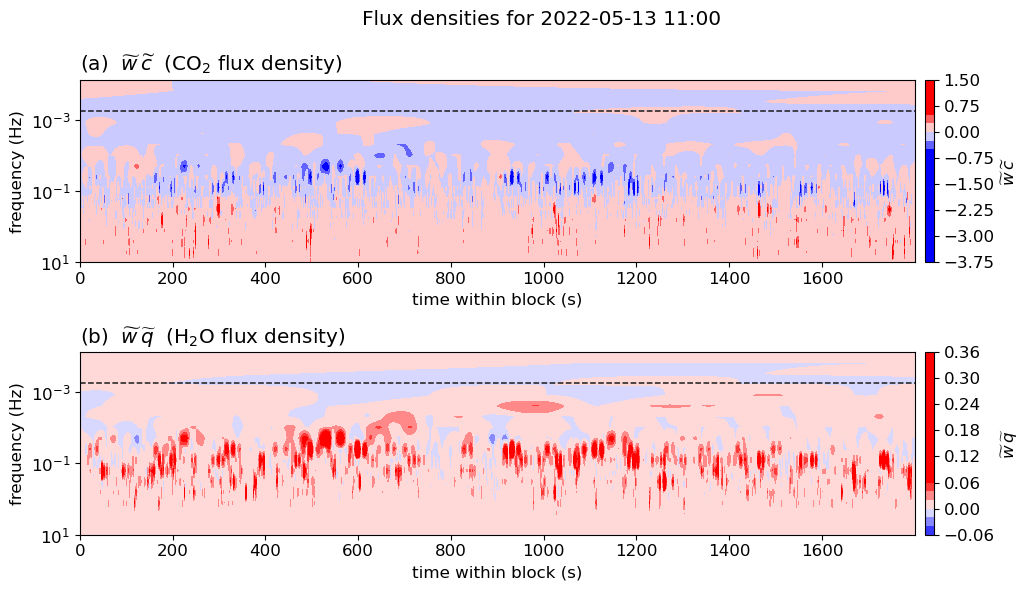

In [3]:
# decompose the detailed half-hour and form the two flux densities (cross-scalograms)
Wd = {v: wavelet_decompose(to_signal(det, v))["wave"] for v in VARS}
WC = Wd["w"] * Wd["co2"]      # w~ c~  -> CO2 flux density in time-frequency
WQ = Wd["w"] * Wd["h2o"]      # w~ q~  -> H2O flux density in time-frequency

fig, ax = plt.subplots(2, 1, figsize=(11, 6))
fig.suptitle(f"Flux densities for {DETAIL_BLOCK:%Y-%m-%d %H:%M}", y=0.98)

plt.colorbar(plot_scalogram(ax[0], WC), ax=ax[0], pad=0.01).set_label(r"$\widetilde{w}\,\widetilde{c}$")
ax[0].set_title(r"(a)  $\widetilde{w}\,\widetilde{c}$  (CO$_2$ flux density)", loc="left")

plt.colorbar(plot_scalogram(ax[1], WQ), ax=ax[1], pad=0.01).set_label(r"$\widetilde{w}\,\widetilde{q}$")
ax[1].set_title(r"(b)  $\widetilde{w}\,\widetilde{q}$  (H$_2$O flux density)", loc="left")

fig.tight_layout()
plt.show()

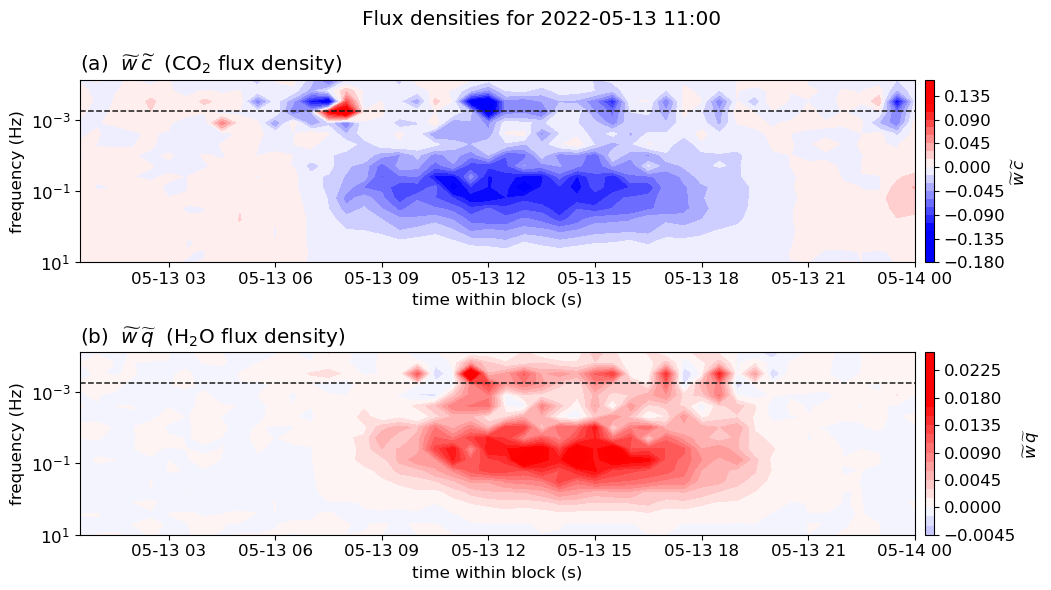

In [4]:
# per-30-min wavelet flux over the whole window
def compute_flux(g):
    # define TIMESTAMP coordinate based on TIMESTAMP_nc 30min block timestamp later
    Wd = {v: wavelet_decompose(to_signal(g, v))["wave"] for v in VARS}
    WC = Wd["w"] * Wd["co2"]      # w~ c~  -> CO2 flux density in time-frequency
    WQ = Wd["w"] * Wd["h2o"]      # w~ q~  -> H2O flux density in time-frequency
    return {"WC": WC.mean('TIMESTAMP_ns'), "WQ": WQ.mean('TIMESTAMP_ns')}

# Apply the function to each group and combine results
wave_flux = xr.concat([xr.Dataset(compute_flux(g)).assign_coords(TIMESTAMP=t)
                       for t, g in data.groupby("TIMESTAMP")], dim="TIMESTAMP")

fig, ax = plt.subplots(2, 1, figsize=(11, 6))
fig.suptitle(f"Flux densities for {DETAIL_BLOCK:%Y-%m-%d %H:%M}", y=0.98)

plt.colorbar(plot_scalogram(ax[0], wave_flux.WC.T), ax=ax[0], pad=0.01).set_label(
    r"$\widetilde{w}\,\widetilde{c}$")
ax[0].set_title(
    r"(a)  $\widetilde{w}\,\widetilde{c}$  (CO$_2$ flux density)", loc="left")

plt.colorbar(plot_scalogram(ax[1], wave_flux.WQ.T), ax=ax[1], pad=0.01).set_label(
    r"$\widetilde{w}\,\widetilde{q}$")
ax[1].set_title(
    r"(b)  $\widetilde{w}\,\widetilde{q}$  (H$_2$O flux density)", loc="left")

fig.tight_layout()
plt.show()

## 3. Conditional sampling: the four quadrants

Labelling each coefficient by the joint sign of $\widetilde{w}\widetilde{c}$ and
$\widetilde{w}\widetilde{q}$ gives four quadrants:

| Quadrant | $\widetilde{w}\widetilde{c}$ | $\widetilde{w}\widetilde{q}$ | interpretation | role |
|---|:---:|:---:|---|---|
| $Q_1$ | $+$ (up) | $+$ (up) | respiration during evaporation | R$_{eco}$ |
| $Q_2$ | $+$ (up) | $-$ (down) | respiration during condensation | R$_{eco}$ |
| $Q_3$ | $-$ (down) | $-$ (down) | uptake **without** transpiration — ambiguous | split |
| $Q_4$ | $-$ (down) | $+$ (up) | **photosynthesis** with transpiration | GPP |

The physically clean signals are $Q_4$ (uptake paired with transpiration → photosynthesis) and $Q_1$
(release → respiration). $Q_3$ — CO$_2$ uptake with no accompanying water release — cannot be stomatal
photosynthesis, so it is treated as ambiguous and split (§4).

We register the four quadrants as masks in a small catalogue, so the figures and the partitioning all
read from one definition rather than repeating the sign rules.

In [5]:
# The four quadrants of the (w~c~, w~q~) plane as a small named catalogue. Each entry is a
# boolean mask over the time-frequency coefficients plus the metadata the figures and the
# partitioning read back: a panel title and the gross-flux role it plays.
QUADRANTS = create_registry(
    "CO2-flux quadrants by the joint sign of the w-CO2 and w-H2O cross-scalograms.")


def _quadrant(name, title, interp, role):
    return register(name, QUADRANTS, description=interp, title=title, role=role)


@_quadrant("Q1", r"$Q_1$:  $\widetilde{w}\widetilde{c}>0,\ \widetilde{w}\widetilde{q}>0$",
           "CO2 up, H2O up - respiration co-occurring with evaporation", role="Reco")
def q1(wc, wq):
    return (wc > 0) & (wq > 0)


@_quadrant("Q2", r"$Q_2$:  $\widetilde{w}\widetilde{c}>0,\ \widetilde{w}\widetilde{q}<0$",
           "CO2 up, H2O down - respiration co-occurring with condensation", role="Reco")
def q2(wc, wq):
    return (wc > 0) & (wq < 0)


@_quadrant("Q3", r"$Q_3$:  $\widetilde{w}\widetilde{c}<0,\ \widetilde{w}\widetilde{q}<0$",
           "CO2 down, H2O down - uptake without transpiration (ambiguous; split)", role="split")
def q3(wc, wq):
    return (wc < 0) & (wq < 0)


@_quadrant("Q4", r"$Q_4$:  $\widetilde{w}\widetilde{c}<0,\ \widetilde{w}\widetilde{q}>0$",
           "CO2 down, H2O up - photosynthesis paired with transpiration", role="GPP")
def q4(wc, wq):
    return (wc < 0) & (wq > 0)


for name, fn in QUADRANTS.items():
    print(f"{name}  ({fn.role:>4s})  {fn._description}")

Q1  (Reco)  CO2 up, H2O up - respiration co-occurring with evaporation
Q2  (Reco)  CO2 up, H2O down - respiration co-occurring with condensation
Q3  (split)  CO2 down, H2O down - uptake without transpiration (ambiguous; split)
Q4  ( GPP)  CO2 down, H2O up - photosynthesis paired with transpiration


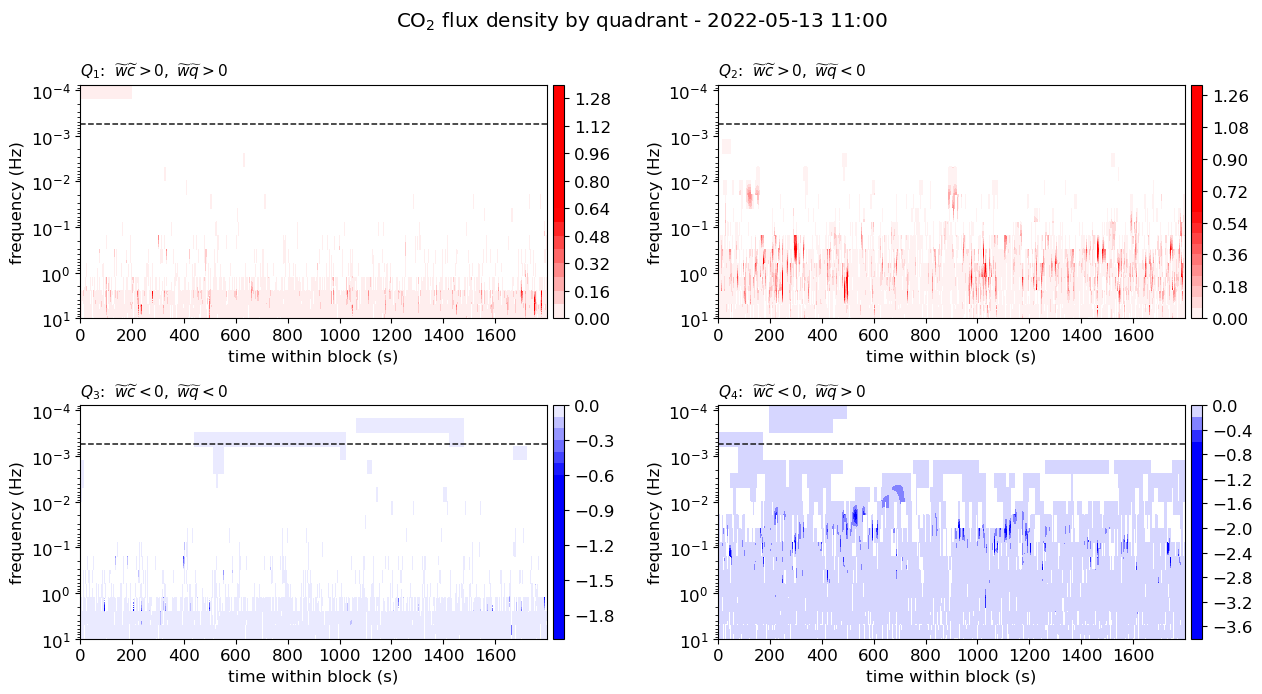

In [6]:
# the CO2 flux density restricted to each quadrant, for the detailed half-hour
vmax = float(np.nanquantile(np.abs(WC.values), 0.99))

fig, ax = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle(f"CO$_2$ flux density by quadrant - {DETAIL_BLOCK:%Y-%m-%d %H:%M}", y=0.99)

for axis, (name, fn) in zip(ax.flat, QUADRANTS.items()):
    panel = WC.where(fn(WC, WQ))                 # NaN outside the quadrant
    plt.colorbar(plot_scalogram(axis, panel, vmax=vmax), ax=axis, pad=0.01)
    axis.set_title(fn.title, loc="left", fontsize=11)

fig.tight_layout()
plt.show()

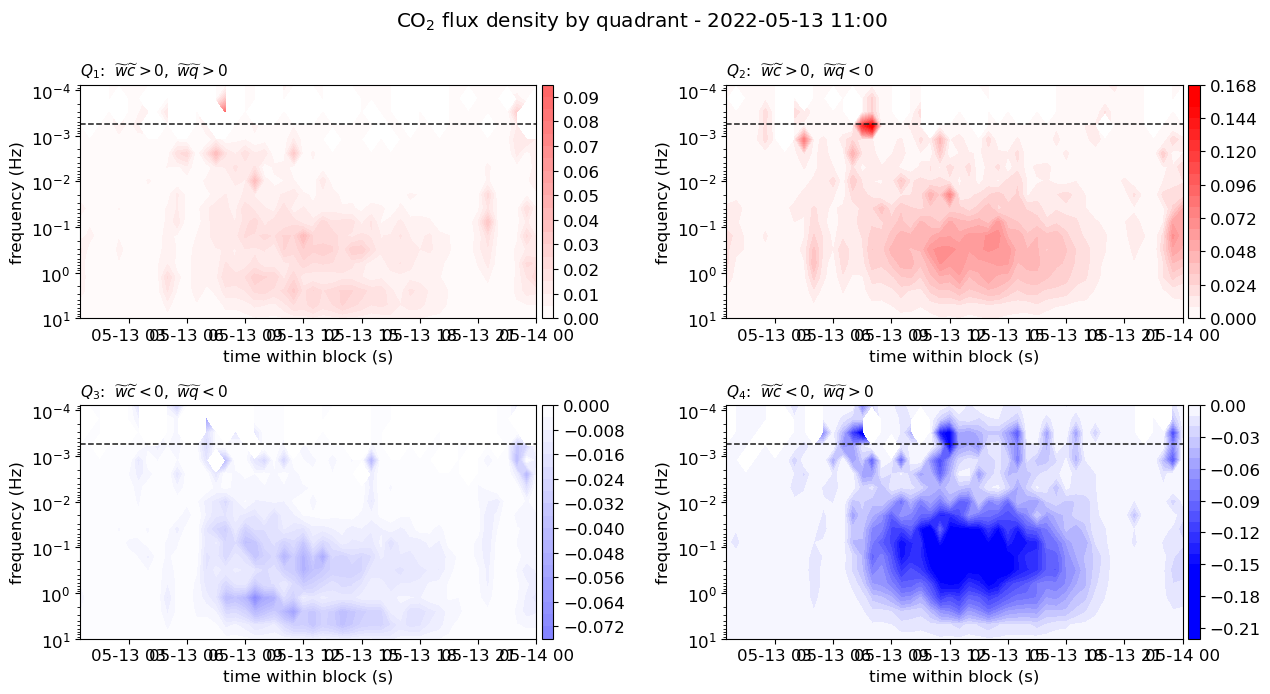

In [7]:
# per-30-min wavelet flux over the whole window
# (this is exactly what the production pipeline does for each averaging period)
def compute_flux(g):
    cw = wavelet_decompose(to_signal(g, "w"))["wave"]
    cc = wavelet_decompose(to_signal(g, "co2"))["wave"]
    cq = wavelet_decompose(to_signal(g, "h2o"))["wave"]
    WC = cw * cc
    WQ = cw * cq
    return {name: WC.where(fn(WC, WQ)).mean('TIMESTAMP_ns') for name, fn in QUADRANTS.items()}


# Apply the function to each group and combine results
wave_flux = xr.concat([xr.Dataset(compute_flux(g)).assign_coords(TIMESTAMP=t) \
                         for t, g in data.groupby("TIMESTAMP")], dim="TIMESTAMP")

vmax = float(np.nanquantile(np.abs(wave_flux.to_dataarray()), 0.99))

fig, ax = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle(
    f"CO$_2$ flux density by quadrant - {DETAIL_BLOCK:%Y-%m-%d %H:%M}", y=0.99)

for axis, (name, fn) in zip(ax.flat, QUADRANTS.items()):
    # average over time to get a frequency-only profile
    panel = wave_flux[name].T
    plt.colorbar(plot_scalogram(axis, panel, vmax=vmax), ax=axis, pad=0.01)
    axis.set_title(fn.title, loc="left", fontsize=11)

fig.tight_layout()
plt.show()

## 4. Partitioning NEE into GPP and respiration

For each 30-minute block we sum the CO$_2$ cross-scalogram over the turbulent scales **within each
quadrant** and average over the block, giving four numbers $Q_1\ldots Q_4$ whose sum is the net flux:

$$\text{NEE} \;=\; Q_1 + Q_2 + Q_3 + Q_4 \;=\; \overline{\widetilde{w}\widetilde{c}}\,\big|_{\text{turbulent}}.$$

A **sign-only** split calls every downward coefficient photosynthesis, $\text{GPP}=Q_3+Q_4$. But $Q_3$
is uptake with **no** transpiration, which stomatal photosynthesis cannot produce. The
**H$_2$O-conditioned** scheme of Coimbra et al. (2025) therefore credits only the transpiration-paired
uptake to photosynthesis and splits the ambiguous $Q_3$ evenly:

$$\text{GPP} \;=\; Q_4 + \tfrac{1}{2}Q_3,\qquad R_{eco} \;=\; \text{NEE}-\text{GPP} \;=\; Q_1 + Q_2 + \tfrac{1}{2}Q_3.$$

Here GPP is negative (a downward, into-canopy flux) and $R_{eco}$ positive; they sum back to NEE, so
the net flux is untouched — only its attribution changes. Both schemes are registered below so they
can be swapped by name; the figure shows the H$_2$O scheme with the sign-only result dotted for
contrast.

In [8]:
def quadrant_fluxes(g):
    """Quadrant-resolved CO2 flux for one block: sum over turbulent scales, mean over time."""
    cw = wavelet_decompose(to_signal(g, "w"))["wave"]
    cc = wavelet_decompose(to_signal(g, "co2"))["wave"]
    cq = wavelet_decompose(to_signal(g, "h2o"))["wave"]
    wc, wq = cw * cc, cw * cq
    turb = wc.natural_frequency >= CUTOFF_HZ
    return {name: wc.where(fn(wc, wq), 0.0)
                          .where(turb, drop=True).mean('TIMESTAMP_ns')
            for name, fn in QUADRANTS.items()}


# one row per 30-min block, one column per quadrant
Q = xr.concat([xr.Dataset(quadrant_fluxes(g)).assign_coords(
    {"TIMESTAMP": t}) for t, g in data.groupby("TIMESTAMP")], dim='TIMESTAMP')
# Q = pd.DataFrame({t: quadrant_fluxes(g) for t, g in data.groupby("TIMESTAMP")}).T
# Q.index = pd.to_datetime(Q.index)
Q = Q[list(QUADRANTS)]

# Two ways to turn the quadrants into NEE / GPP / Reco, registered so they swap by name.
SCHEMES = create_registry("Partitioning schemes: quadrant fluxes -> NEE / GPP / Reco.")


@register("sign", SCHEMES, description="Sign of w-CO2 only: all uptake is GPP, all release is Reco.")
def sign_only(q):
    nee = q[list(QUADRANTS)].to_array().sum(
        ['variable'])
    gpp = q["Q3"] + q["Q4"]                       # every downward (uptake) coefficient
    return xr.Dataset({"NEE": nee, "GPP": gpp, "Reco": nee - gpp})


@register("h2o", SCHEMES,
          description="Conditional sampling on w-H2O: GPP = Q4 + 1/2 Q3 (Coimbra et al. 2025).")
def h2o_conditioned(q):
    nee = q[list(QUADRANTS)].to_array().sum(
        ['variable'])
    gpp = q["Q4"] + 0.5 * q["Q3"]                 # only transpiration-paired uptake
    return xr.Dataset({"NEE": nee, "GPP": gpp, "Reco": nee - gpp})


@register("uncertain", SCHEMES,
          description="Q3 is uncertain: GPP = Q4 - Q3. Reco = Q1 + Q2 + 2xQ3.")
def uncertain(q):
    nee = q[list(QUADRANTS)].to_array().sum(
        ['variable'])
    # only transpiration-paired uptake
    gpp = q["Q4"] - q["Q3"]
    return xr.Dataset({"NEE": nee, "GPP": gpp, "Reco": nee - gpp})


part = {name: scheme(Q) for name, scheme in SCHEMES.items()}
part["uncertain"].to_dataframe().head()

NEE           GPP          Reco
natural_frequency TIMESTAMP                                                
10.0              2022-05-13 00:30:00  0.000037  1.789942e-06  3.560971e-05
                  2022-05-13 01:00:00  0.000023 -9.937296e-07  2.386791e-05
                  2022-05-13 01:30:00  0.000054 -4.149306e-06  5.845611e-05
                  2022-05-13 02:00:00  0.000001  1.920948e-06 -6.537761e-07
                  2022-05-13 02:30:00 -0.000002 -4.373165e-06  2.087712e-06

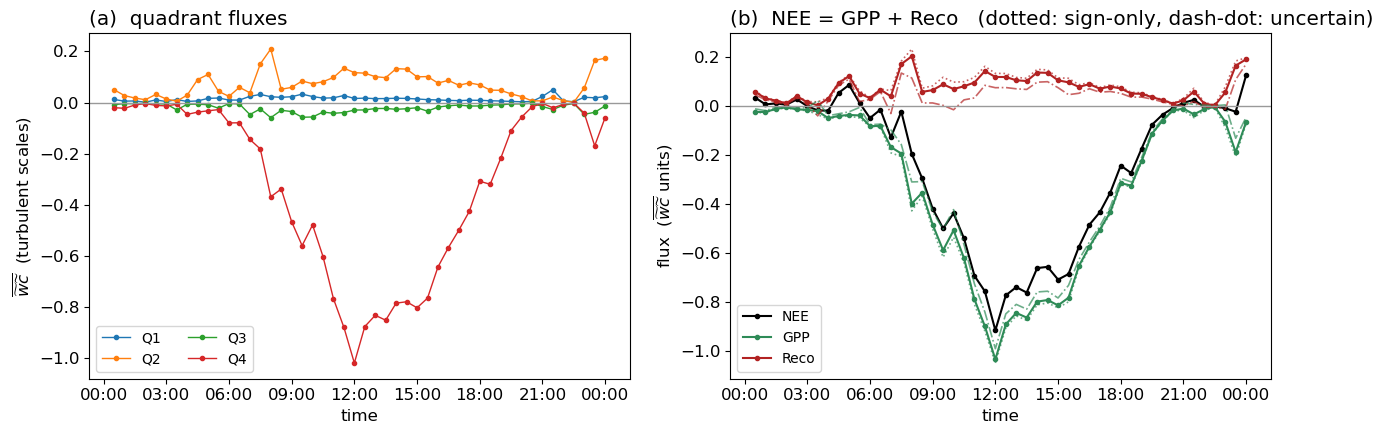

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) the four quadrant fluxes through the day
for name in QUADRANTS:
    ax[0].plot(Q.TIMESTAMP, Q[name].sum('natural_frequency'), ".-", lw=1, label=name)
ax[0].axhline(0, color="0.6", lw=1)
ax[0].xaxis.set_major_formatter(DateFormatter("%H:%M"))
ax[0].set_ylabel(r"$\overline{\widetilde{w}\widetilde{c}}$  (turbulent scales)")
ax[0].set_xlabel("time")
ax[0].set_title("(a)  quadrant fluxes", loc="left")
ax[0].legend(ncol=2, fontsize=10)

# (b) NEE / GPP / Reco from the H2O-conditioned scheme; sign-only shown dotted
p, p0, p1 = part["h2o"].sum('natural_frequency'), part["sign"].sum('natural_frequency'), part["uncertain"].sum('natural_frequency')  # the two schemes to compare
colors = {"NEE": "k", "GPP": "seagreen", "Reco": "firebrick"}
for k, c in colors.items():
    ax[1].plot(p.TIMESTAMP, p[k], color=c, marker=".", label=k)
for k in ("GPP", "Reco"):
    ax[1].plot(p0.TIMESTAMP, p0[k], color=colors[k], lw=1.2, ls=":", alpha=0.7)
for k in ("GPP", "Reco"):
    ax[1].plot(p1.TIMESTAMP, p1[k], color=colors[k], lw=1.2, ls="-.", alpha=0.7)
ax[1].axhline(0, color="0.6", lw=1)
ax[1].xaxis.set_major_formatter(DateFormatter("%H:%M"))
ax[1].set_ylabel(r"flux  ($\overline{\widetilde{w}\widetilde{c}}$ units)")
ax[1].set_xlabel("time")
ax[1].set_title("(b)  NEE = GPP + Reco   (dotted: sign-only, dash-dot: uncertain)", loc="left")
ax[1].legend(fontsize=10)

fig.tight_layout()
plt.show()

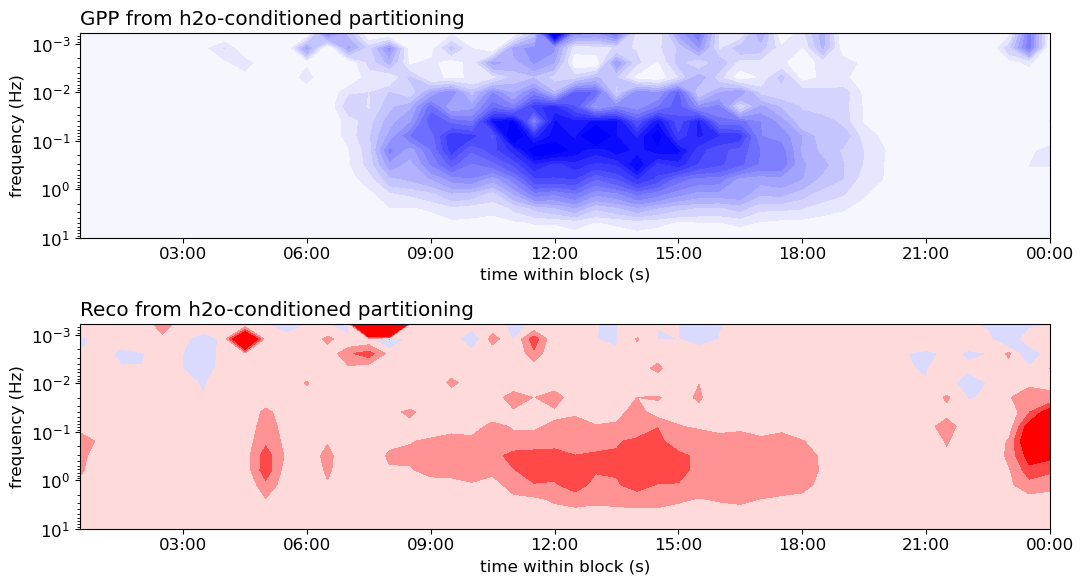

In [10]:
# figsize: (11, 6) default, (13, 4.5) for extra wide
fig, ax = plt.subplots(2, 1, figsize=(11, 6))

meth = "h2o"

for i, k in enumerate(("GPP", "Reco")):
    plot_scalogram(ax[i], part[meth][k].T)
    ax[i].xaxis.set_major_formatter(DateFormatter("%H:%M"))
    ax[i].set_title(f"{k} from {meth}-conditioned partitioning", loc="left")

fig.tight_layout()
plt.show()

## 5. The production pipeline

The by-hand version above is the transparent form of what `waveletec` runs for you — same
decomposition, same quadrants, same partitioning — wrapped into a single call.

In [11]:
# Internally the pipeline decomposes each averaging period (`decompose_variables`),
# conditionally samples the flux on H2O (`data_conditional_sampling` with the formula
# "w*co2|w*h2o", whose wco2(+/-)wh2o(+/-) components are exactly Q1..Q4 above), integrates
# over the turbulent scales (`data_integrate_in_frequency`) and partitions into NEE / GPP /
# Reco (`data_partition`, applying GPP = Q4 + 1/2 Q3 just as in section 4).
#
# A full run is one call. Left commented so the notebook stays light:

# wEC.run_from_eddypro(
#     "input/EP/FR-Gri_sample.eddypro",
#     input_path="output/eddypro_raw_datasets/level_6",
#     output_folderpath="output/wavelet_flux",
# )
# fluxes = wEC.open_files_in_folder("output/wavelet_flux")   # NEE, GPP, Reco per period

## Summary

| | sign-only | H$_2$O-conditioned (this notebook) |
|---|---|---|
| Second scalar | none | H$_2$O (transpiration) |
| GPP | $Q_3 + Q_4$ (all uptake) | $Q_4 + \tfrac{1}{2}Q_3$ (transpiration-paired) |
| R$_{eco}$ | $Q_1 + Q_2$ | $Q_1 + Q_2 + \tfrac{1}{2}Q_3$ |
| Uptake without transpiration counts as | photosynthesis | ambiguous (split) |
| NEE | $\sum_i Q_i$ | $\sum_i Q_i$ (unchanged) |

Both partitions return the **same NEE**; conditional sampling only changes how that net flux is split
between the two gross components.

**API / implementation notes**

- The quadrant masks and the two partitioning schemes live in `regorator` registries
  (`create_registry` / `register`) — the one third-party dependency beyond the scientific stack and
  `waveletec` itself. It buys a single self-documenting definition of each quadrant (sign rule, panel
  title, partition role) that both the figures and the partitioning iterate over, in place of four
  near-identical blocks.
- These definitions match `waveletec`'s built-in conditional sampling: the `wco2(+/-)wh2o(+/-)`
  components from `data_conditional_sampling(ds, "w*co2|w*h2o")` are $Q_1\ldots Q_4$, and
  `data_partition` applies the same $\text{GPP}=Q_4+\tfrac{1}{2}Q_3$.
- Everything else (`wavelet_transform`, `natural_frequency` carrying band frequencies in Hz, the
  writable-array requirement of `to_signal`, the `>= 1/1800`\,Hz turbulent cut-off) is unchanged from
  the comparison notebook.